# Phase 4: Spatial Architecture Matrix

This notebook asks the model for approximate object coordinates on a layout-style image, then optionally compares the output with a deterministic reference such as Textract or manually labeled boxes.

In [1]:
%pip install -q openai pillow pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display
from PIL import Image, ImageDraw

from vision_lab_utils import (
    build_response_record,
    call_vision_json,
    ensure_dir,
    estimate_bbox_iou,
    get_client,
    read_json,
    save_json,
)

client = get_client()
ROOT = Path.cwd()
IMAGE_DIR = ensure_dir(ROOT / "images" / "spatial")
OUTPUT_DIR = ensure_dir(ROOT / "outputs")

LAYOUT_IMAGE_PATH = ROOT / "layout_image.png"
REFERENCE_PATH = ROOT / "reference_boxes.json"

TARGET_OBJECTS = [
    "sink",
    "refrigerator",
    "table",
    "door",
]


If `layout_image.png` does not exist yet, add your kitchen, floorplan, or layout image to the notebook folder and update `LAYOUT_IMAGE_PATH` in the setup cell.

In [6]:
assert LAYOUT_IMAGE_PATH.exists(), f"Layout image not found: {LAYOUT_IMAGE_PATH}"

In [7]:
SPATIAL_PROMPT = f"""
You are a spatial-analysis assistant.

Analyze the attached layout image and identify these target objects:
{', '.join(TARGET_OBJECTS)}

For each object:
1. Estimate its pixel coordinates as the center point (x, y).
2. Provide a bounding box estimate as [x_min, y_min, x_max, y_max].
3. Give a confidence score from 0 to 1.
4. Explain briefly if the estimate is approximate.

Important:
- Coordinates do not need to be perfect, but they must be grounded in the image.
- If the object is ambiguous or not visible, say so clearly.
- Do not invent precision beyond what can be inferred visually.

Return only valid JSON in this form:
{{
  \"objects\": [
    {{
      \"name\": \"object name\",
      \"center\": {{\"x\": 0, \"y\": 0}},
      \"bbox\": [0, 0, 0, 0],
      \"confidence\": 0.0,
      \"notes\": \"...\"
    }}
  ]
}}
""".strip()

In [8]:
parsed, response = call_vision_json(
    client,
    model="gpt-4.1-mini",
    prompt=SPATIAL_PROMPT,
    image_path=LAYOUT_IMAGE_PATH,
    detail="high",
)

record = build_response_record(
    model="gpt-4.1-mini",
    detail="high",
    image_path=LAYOUT_IMAGE_PATH,
    prompt=SPATIAL_PROMPT,
    parsed=parsed,
    response=response,
)

save_json(OUTPUT_DIR / "phase4_spatial.json", record)
parsed

{'objects': [{'name': 'sink',
   'center': {'x': 808, 'y': 275},
   'bbox': [765, 245, 850, 300],
   'confidence': 0.9,
   'notes': 'Located in the kitchen area at the top center part near the window; estimate based on typical sink placement.'},
  {'name': 'refrigerator',
   'center': {'x': 880, 'y': 327},
   'bbox': [860, 290, 900, 360],
   'confidence': 0.85,
   'notes': 'Located to the right of the kitchen stove, fridge size and shape inferred from layout.'},
  {'name': 'table',
   'center': {'x': 710, 'y': 490},
   'bbox': [620, 425, 800, 555],
   'confidence': 0.95,
   'notes': 'Dining table in the living/dining area near the bottom right quadrant clearly visible.'},
  {'name': 'door',
   'center': {'x': 637, 'y': 550},
   'bbox': [615, 535, 665, 565],
   'confidence': 0.9,
   'notes': 'Main entrance door to the living/dining area from the porch area at bottom center identified by door arc.'}]}

In [9]:
objects_df = pd.DataFrame(parsed.get("objects", []))
objects_df

,name,center,bbox,confidence,notes
0,sink,"{'x': 808, 'y': 275}","[765, 245, 850, 300]",0.90,Located in the kitchen area at the top center ...
1,refrigerator,"{'x': 880, 'y': 327}","[860, 290, 900, 360]",0.85,"Located to the right of the kitchen stove, fri..."
2,table,"{'x': 710, 'y': 490}","[620, 425, 800, 555]",0.95,Dining table in the living/dining area near th...
3,door,"{'x': 637, 'y': 550}","[615, 535, 665, 565]",0.90,Main entrance door to the living/dining area f...


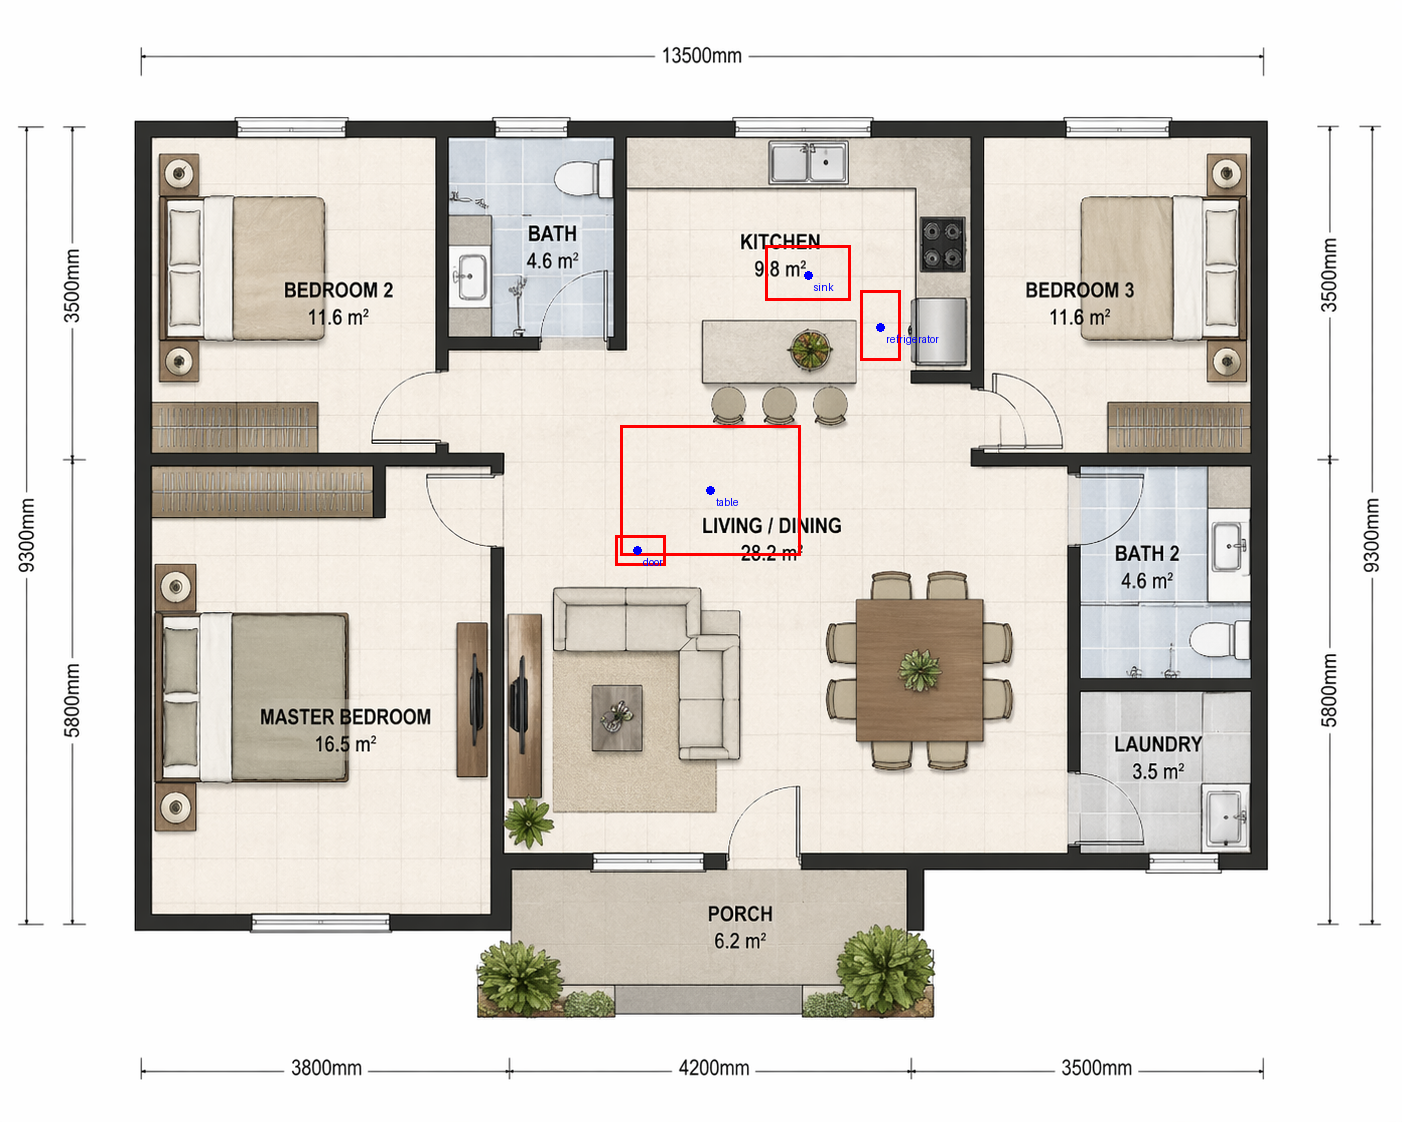

In [11]:
with Image.open(LAYOUT_IMAGE_PATH) as image:
    preview = image.copy()

draw = ImageDraw.Draw(preview)
for item in parsed.get("objects", []):
    bbox = item.get("bbox", [])
    center = item.get("center", {})
    if len(bbox) == 4:
        draw.rectangle(bbox, outline="red", width=3)
    if "x" in center and "y" in center:
        x, y = center["x"], center["y"]
        draw.ellipse((x - 4, y - 4, x + 4, y + 4), fill="blue")
        draw.text((x + 6, y + 6), item.get("name", "object"), fill="blue")

display(preview)


In [12]:
comparison_rows = []
if REFERENCE_PATH.exists():
    reference = read_json(REFERENCE_PATH)
    reference_by_name = {item['name']: item for item in reference.get('objects', [])}
    for item in parsed.get("objects", []):
        name = item.get("name")
        if name in reference_by_name:
            iou = estimate_bbox_iou(item.get("bbox", [0, 0, 0, 0]), reference_by_name[name].get("bbox", [0, 0, 0, 0]))
            comparison_rows.append({
                "name": name,
                "predicted_bbox": item.get("bbox"),
                "reference_bbox": reference_by_name[name].get("bbox"),
                "iou": round(iou, 4),
            })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

""


In [14]:
if not comparison_df.empty:
    mean_iou = float(comparison_df["iou"].mean())
    if mean_iou >= 0.9:
        coordinate_alignment = "Predicted coordinates are very close to the reference boxes, but they should still be treated as approximate rather than perfectly exact."
    elif mean_iou >= 0.6:
        coordinate_alignment = "Predicted coordinates are directionally useful but not perfectly aligned with the reference boxes."
    else:
        coordinate_alignment = "Predicted coordinates do not align precisely with the reference boxes and are too approximate for exact spatial tasks."
else:
    coordinate_alignment = "No reference boxes were provided, so alignment cannot be measured exactly. The coordinates should be treated as approximate estimates."

evaluation_json = {
    "coordinate_alignment": coordinate_alignment,
    "why_llms_struggle": [
        "Vision-language models infer spatial relationships from compressed visual representations rather than performing exact geometric measurement.",
        "Image resizing, patching, and tokenization reduce pixel-level precision, so bounding boxes are approximate.",
    ],
    "why_not_for_redaction": [
        "Precise redaction needs exact pixel boundaries, while LLM vision outputs are approximate and can drift.",
        "A small localization error can leave sensitive text partially visible, which is unacceptable for compliance or privacy workflows.",
    ],
    "why_textract_lacks_semantics": [
        "Textract-style OCR tools are strong at structured detection and coordinates, but they do not deeply reason about intent, meaning, or cross-region context.",
        "They are better for deterministic extraction than for higher-level semantic interpretation.",
    ],
    "tool_selection_guidance": "Use an LLM for semantic understanding and flexible reasoning, and use OCR/layout tools for deterministic coordinates or redaction-sensitive workflows.",
}

save_json(OUTPUT_DIR / "phase4_spatial_evaluation.json", evaluation_json)
evaluation_json


{'coordinate_alignment': 'No reference boxes were provided, so alignment cannot be measured exactly. The coordinates should be treated as approximate estimates.',
 'why_llms_struggle': ['Vision-language models infer spatial relationships from compressed visual representations rather than performing exact geometric measurement.',
  'Image resizing, patching, and tokenization reduce pixel-level precision, so bounding boxes are approximate.'],
 'why_not_for_redaction': ['Precise redaction needs exact pixel boundaries, while LLM vision outputs are approximate and can drift.',
  'A small localization error can leave sensitive text partially visible, which is unacceptable for compliance or privacy workflows.'],
 'why_textract_lacks_semantics': ['Textract-style OCR tools are strong at structured detection and coordinates, but they do not deeply reason about intent, meaning, or cross-region context.',
  'They are better for deterministic extraction than for higher-level semantic interpretation

Reflection Questions


Coordinate alignment:
The coordinates returned by the model should be treated as approximate rather than exact. In this run, we did not have reference bounding boxes to compare against, so there was no way to measure the model’s exact accuracy.


Why LLMs struggle with pixel geometry:
Vision models understand where objects are by interpreting the image visually, not by measuring exact pixels. Since the image is resized and broken into smaller parts during processing, some positional accuracy is naturally lost.


Why GPT vision is not suitable for redaction:
Redaction requires extremely accurate boundaries. If the predicted box is even slightly off, part of the sensitive information may remain visible, which makes approximate vision outputs unsafe for redaction.


Why Textract is not enough for semantics:
Tools like Textract are very good at extracting text and coordinates, but they do not understand the broader meaning or context of the content as well as an LLM.


Tool choice conclusion:
Vision LLMs are better when the task requires understanding, interpretation, or reasoning about the image. Traditional OCR/layout tools are better when exact coordinates and precise positioning are important, such as for redaction or strict document processing workflows.